In [1]:
# python -m pip install pandas matplotlib seaborn xlrd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1.

In [2]:
# encoding="utf-8-sig" porque os CSVs têm BOM (ï»¿) no início
t2012 = pd.read_csv(
    "Tabela5-sem_emprego_2012.csv", sep=";", decimal=",", encoding="utf-8-sig"
)
t2026 = pd.read_csv(
    "Tabela5-sem_emprego_2026.csv", sep=";", decimal=",", encoding="utf-8-sig"
)
t2012.head()

,Sigla,Código,Estado,Desocupados - homens (2012 T1),Desocupados - mulheres (2012 T1)
0,AC,12,Acre,45.3,54.7
1,AL,27,Alagoas,44.7,55.3
2,AM,13,Amazonas,47.5,52.5
3,AP,16,Amapá,48.1,51.9
4,BA,29,Bahia,43.8,56.2


In [3]:
# Renomeia para colunas curtas, já indicando o ano
t2012 = t2012.rename(columns={
    "Desocupados - homens (2012 T1)": "homens_2012",
    "Desocupados - mulheres (2012 T1)": "mulheres_2012",
})
t2026 = t2026.rename(columns={
    "Desocupados - homens (2026 T1)": "homens_2026",
    "Desocupados - mulheres (2026 T1)": "mulheres_2026",
})
t2026.head()

,Sigla,Código,Estado,homens_2026,mulheres_2026
0,AC,12,Acre,53.2,46.8
1,AL,27,Alagoas,50.7,49.3
2,AM,13,Amazonas,46.8,53.2
3,AP,16,Amapá,51.1,48.9
4,BA,29,Bahia,44.7,55.3


## 2.

In [4]:
comp = t2012.merge(t2026, on=["Sigla", "Código", "Estado"], how="inner")
comp["variacao_mulheres_pp"] = comp["mulheres_2026"] - comp["mulheres_2012"]
comp.sort_values("variacao_mulheres_pp")

,Sigla,Código,Estado,homens_2012,mulheres_2012,homens_2026,mulheres_2026,variacao_mulheres_pp
0,AC,12,Acre,45.3,54.7,53.2,46.8,-7.9
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1,-6.9
8,GO,52,Goiás,41.0,59.0,47.5,52.5,-6.5
1,AL,27,Alagoas,44.7,55.3,50.7,49.3,-6.0
17,PR,41,Paraná,40.3,59.7,46.3,53.7,-6.0
10,MG,31,Minas Gerais,43.1,56.9,48.6,51.4,-5.5
13,PA,15,Pará,43.2,56.8,48.3,51.7,-5.1
15,PE,26,Pernambuco,43.9,56.1,48.7,51.3,-4.8
22,RS,43,Rio Grande do Sul,42.8,57.2,47.4,52.6,-4.6
14,PB,25,Paraíba,44.4,55.6,48.9,51.1,-4.5


## 3.
A tabela original traz Brasil, as 5 Grandes Regiões e os 27 estados/UFs, nessa ordem
(Brasil, Norte, seus estados, Nordeste, seus estados...). Para cruzar com a Tabela 5
(que só tem estados), removemos a linha "Brasil" e as 5 linhas de região.

In [5]:
bruto = pd.read_excel("Tabela_1_1_1.xls", engine="xlrd", header=None)

indicador_1 = bruto.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao",
    "total",
    "total_branca",
    "total_preta_parda",
    "homem_branca",
    "homem_preta_parda",
    "mulher_branca",
    "mulher_preta_parda",
]

regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
indicador_estados = indicador_1[~indicador_1["uf_regiao"].isin(["Brasil"] + regioes)].copy()
indicador_estados = indicador_estados.rename(columns={"uf_regiao": "Estado"})
indicador_estados

,Estado,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
10,Rondônia,17.014162,16.727733,17.101523,12.111127,12.54408,20.412887,21.06141
11,Acre,13.606903,13.806929,13.541399,10.79612,9.686983,16.130352,16.710754
12,Amazonas,16.80729,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
13,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
14,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.83511,21.591144
15,Amapá,13.586656,14.38918,13.415091,11.116821,10.749444,16.648579,15.908487
16,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399
18,Maranhão,16.669614,16.421773,16.708894,11.665173,11.437359,19.881056,20.739589
19,Piauí,17.960366,16.948094,18.231789,12.258324,11.204814,20.494063,23.69544
20,Ceará,19.499293,18.52712,19.882469,12.186936,12.821323,23.019718,24.952274


## 4.

In [6]:
comp = comp.merge(indicador_estados, on="Estado", how="inner")
comp

,Sigla,Código,Estado,homens_2012,mulheres_2012,homens_2026,mulheres_2026,variacao_mulheres_pp,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,AC,12,Acre,45.3,54.7,53.2,46.8,-7.9,13.606903,13.806929,13.541399,10.79612,9.686983,16.130352,16.710754
1,AL,27,Alagoas,44.7,55.3,50.7,49.3,-6.0,20.217129,19.165111,20.560451,12.121839,13.35716,24.093655,25.856637
2,AM,13,Amazonas,47.5,52.5,46.8,53.2,0.7,16.80729,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
3,AP,16,Amapá,48.1,51.9,51.1,48.9,-3.0,13.586656,14.38918,13.415091,11.116821,10.749444,16.648579,15.908487
4,BA,29,Bahia,43.8,56.2,44.7,55.3,-0.9,17.849776,17.538007,17.935566,10.551673,10.982808,22.57273,23.217119
5,CE,23,Ceará,51.1,48.9,52.7,47.3,-1.6,19.499293,18.52712,19.882469,12.186936,12.821323,23.019718,24.952274
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1,-6.9,15.096351,15.061306,15.126295,11.377952,10.481279,17.738123,19.307332
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5,-1.1,17.111106,16.51061,17.478861,11.798571,12.017589,20.464462,22.196626
8,GO,52,Goiás,41.0,59.0,47.5,52.5,-6.5,15.186471,14.962622,15.296966,10.636424,10.531883,18.440842,19.587913
9,MA,21,Maranhão,47.2,52.8,49.1,50.9,-1.9,16.669614,16.421773,16.708894,11.665173,11.437359,19.881056,20.739589


## 5.

In [7]:
ordem = comp.sort_values("mulheres_2026")["Estado"]

longo = comp.melt(
    id_vars=["Sigla", "Código", "Estado"],
    value_vars=["mulheres_2012", "mulheres_2026"],
    var_name="Ano",
    value_name="Participacao_mulheres",
)
longo["Ano"] = longo["Ano"].map({"mulheres_2012": "2012 T1", "mulheres_2026": "2026 T1"})
longo.head()

,Sigla,Código,Estado,Ano,Participacao_mulheres
0,AC,12,Acre,2012 T1,54.7
1,AL,27,Alagoas,2012 T1,55.3
2,AM,13,Amazonas,2012 T1,52.5
3,AP,16,Amapá,2012 T1,51.9
4,BA,29,Bahia,2012 T1,56.2


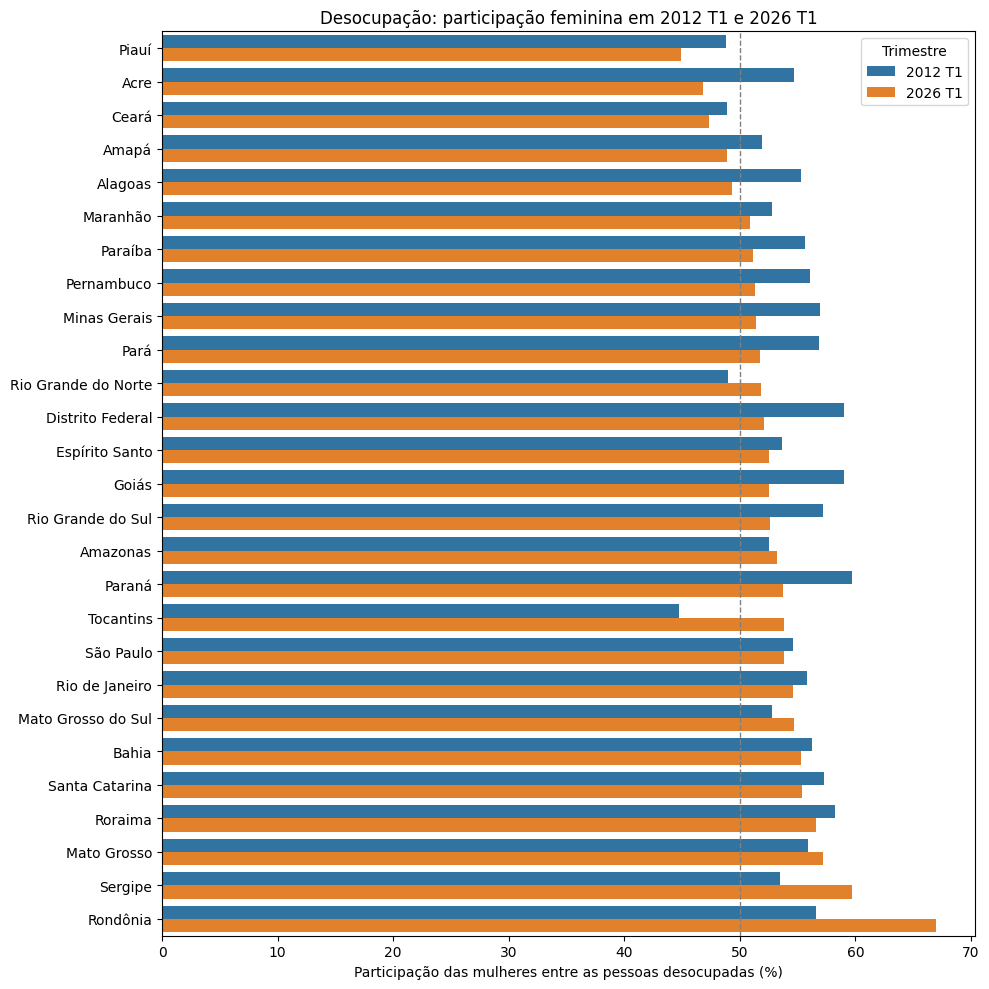

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    data=longo,
    y="Estado",
    x="Participacao_mulheres",
    hue="Ano",
    order=ordem,
    ax=ax,
)
ax.axvline(50, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
ax.legend(title="Trimestre")
fig.tight_layout()
plt.savefig("graficos/desocupacao_mulheres_2012_2026.png", dpi=150)
plt.show()